In [3]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3



In [4]:
#Excel file path
excel_file = '/content/customer_churn_data_raw.xlsx'

# Create SQLite database connection
conn = sqlite3.connect('/content/customer_churn.db')

# Read all sheet names from Excel file
excel_data = pd.ExcelFile(excel_file)

# Loop through each sheet and store as separate table
for sheet in excel_data.sheet_names:
    df = pd.read_excel(excel_file, sheet_name=sheet) # Read sheet into dataframe
    # Write dataframe to SQLite table
    df.to_sql(
        name=sheet,          # Table name = Sheet name
        con=conn,
        if_exists='replace', # Replace table if already exists
        index=False
    )

# Close connection
conn.close()

print("All sheets successfully converted into SQLite tables.")#

All sheets successfully converted into SQLite tables.


In [5]:
#1 - import data


In [6]:
# Data Import: db file to pandas, storing each table to a separate df

# Connect to SQLite database
conn = sqlite3.connect('/content/customer_churn.db')

# sql query to Get all table names
sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table';
"""

# read sql query in pandas
tables = pd.read_sql(sql_query, conn)

# create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn) # Read table into dataframe
    globals()[f"df_{table_name}"] = df                    # Create dynamic dataframe name
    print(f"Created dataframe: df_{table_name}")

# Close connection
conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [7]:
#print table names and column names
conn = sqlite3.connect('/content/customer_churn.db')

for table_name in tables['name']:
  print(f"\nTable Name: {table_name}")
  #get column information
  columns_query = f"PRAGMA table_info({table_name});"
  columns = pd.read_sql(columns_query, conn)
  print("columns:")
  print(columns['name'].tolist)

conn.close()


Table Name: db_customer
columns:
<bound method IndexOpsMixin.tolist of 0    customerid
1          name
2       country
3         state
4        gender
5           dob
6     interests
7       pincode
Name: name, dtype: object>

Table Name: db_subscription
columns:
<bound method IndexOpsMixin.tolist of 0                  customerid
1     subscription_start_date
2           subscription_type
3                renewal_date
4                   plan_type
5               contract_type
6           cancellation_date
7         cancellation_reason
8             monthly_charges
9                        cltv
10                churn_score
Name: name, dtype: object>

Table Name: db_support
columns:
<bound method IndexOpsMixin.tolist of 0        customerid
1    complaint_date
2       escalations
3        csat_score
4             col_1
5           comment
Name: name, dtype: object>


In [8]:
# 2 -- > data cleaning

In [9]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [10]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [11]:
# rename the name collumn

df_db_customer.rename(columns={'name': 'customer_name'}, inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [12]:
#drop intrest and pincode

df_db_customer.drop(columns=['interests', 'pincode'], inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [13]:
# change data type of dob
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])



In [14]:
#data standardization - gender

#df_db_customer['gender'].unique()
df_db_customer['gender'].replace({'Men': 'Male','Women':'Female'},inplace=True)
df_db_customer['gender'].unique()

/tmp/ipykernel_1721/3979960248.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_db_customer['gender'].replace({'Men': 'Male','Women':'Female'},inplace=True)


array(['Male', 'Female'], dtype=object)

In [15]:
#FINDING MISSING VALUES

df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [16]:
df_db_customer[['country' , 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,None,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,None,Kathmandu
9,Nepal,Kathmandu


In [17]:
#country and state - unique value pair

state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country']= df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [18]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [19]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [20]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [21]:
df_db_subscription.info()
df_db_subscription.isna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,False,False,False,False,False,False,True,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,True,True,False,False,False
3,False,False,False,False,False,False,True,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,True,True,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,True,True,False,False,False
8,False,False,False,False,False,False,True,True,False,False,False
9,False,False,False,False,False,False,True,True,False,False,False


In [22]:
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription[date_col]
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [23]:
df_db_support.head()
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [24]:
df_db_support.drop(columns=['col_1', 'comment'], inplace=True)

In [25]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 420.0+ bytes


In [26]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [27]:
# 3   FEATURE ENGINEERING AND DATA ANALYSIS

In [28]:
#create a new column using existing column --> churn_flag

df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notnull(), 1, 0)
df_db_subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,0
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,0
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,41,0


In [29]:
#first fix support table dublicates then merge

df= (df_db_subscription
                 .merge(df_db_customer , on = 'customerid', how = 'left' )
                 .merge(df_db_support , on = 'customerid', how = 'left' ))

In [30]:
df.shape

(23, 20)

In [31]:
df_db_support


,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [32]:
df_db_support['complaint_count'] = df_db_support.groupby("customerid")['customerid'].transform('count')

In [33]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep='last')

In [34]:
#merge dataframes
df= (df_db_subscription
                 .merge(df_db_customer , on = 'customerid', how = 'left' )
                 .merge(df_db_support , on = 'customerid', how = 'left' ))

In [35]:
df.shape

(21, 21)

In [36]:
df.to_csv('exported_churn_data.csv', index=False)

In [37]:
#Data analysis

In [38]:
#1 churn rate

In [39]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [40]:
churn_rate = df['churn_flag'].mean()*100

print("churn_rate = " , round(churn_rate,2), "%")

churn_rate =  28.57 %


In [41]:
#2 Retaintion Rate

retention_rate = 100 - churn_rate

print("retention rate = " , round(retention_rate,2), "%")

retention rate =  71.43 %


In [42]:
# 3  churn by plan type

churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [43]:
churn_by_state = (df.groupby('state')['customerid'].count().reset_index())
print(churn_by_state)

           state  customerid
0          Delhi           4
1      Karnataka           2
2      Kathmandu           2
3    Maharashtra           3
4      Meghalaya           3
5       Nagaland           1
6      Rajasthan           2
7      Telangana           2
8  Uttar Pradesh           2


In [44]:
#ARPU --- Average revenue per users


In [45]:
arpu = df['monthly_charges'].mean()
print("ARPU = " , round(arpu,2))

ARPU =  18.85


In [46]:
 #AVG coustomer Tenure
 # count of days users has used our service : cancellation date else current date
 today = pd.Timestamp.today()
 df['tenure_days'] = np.where(df['cancellation_date'].notna(),
                             (df['cancellation_date'] - df['subscription_start_date']).dt.days,
                             (today - df['subscription_start_date']).dt.days
                              )

avg_tenure = df['tenure_days'].mean()
print("avg_tenure (days) " ,round(avg_tenure),0)

avg_tenure (days)  1496 0


In [47]:
#7 Revenue at risk -- revenue lost from churned users

revenue_at_risk = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()
print("revenue_at_risk (Rs 'K') = " , round(revenue_at_risk,2))

revenue_at_risk (Rs 'K') =  73.94


In [48]:
#8. Esclation Rate

escalations_Rate = (df['escalations']=='Y').mean()*100
print("escalations_Rate = " , round(escalations_Rate,2), "%")

escalations_Rate =  19.05 %


In [49]:
#9. Avg complain per user

avg_complaints =df['complaint_count'].sum()/df['customerid'].nunique()
print("avg_complaints per user = " , round(avg_complaints,2))

avg_complaints per user =  0.43


In [50]:
## 1. Start fresh by merging the raw tables again to restore the original 'Y'/'N' values
df_merged = (df_db_subscription
             .merge(df_db_customer, on='customerid', how='left')
             .merge(df_db_support, on='customerid', how='left'))

# 2. Convert 'escalations' properly:
# - If it's 'Y', it becomes 1
# - If it's 'N', it becomes 0
# - If it's NaN (meaning no support contact), it becomes 0
df_merged['escalations_clean'] = np.where(df_merged['escalations'] == 'Y', 1, 0)

# 3. Convert 'churn_flag' (since it is already numeric 1s and 0s)
df_merged['churn_clean'] = df_merged['churn_flag'].astype(float)

# 4. Calculate the correlation using the freshly merged, clean columns
correlation = df_merged['escalations_clean'].corr(df_merged['churn_clean'])

print("Correlation between escalations and churn = ", round(correlation, 2))

Correlation between escalations and churn =  0.77


In [51]:
#11 chrun risk - create a column using existing col

conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

choices = ['Low', 'Medium', 'High']

df['churn_risk'] = np.select(conditions, choices, default='Unknown')
#

In [52]:
df[['churn_risk','churn_score']].tail()

,churn_risk,churn_score
16,Medium,62
17,Low,27
18,High,99
19,Low,7
20,Low,47


In [53]:
#5 ---> Visualisation using Matplotlib

In [54]:
df_visual = df.copy()

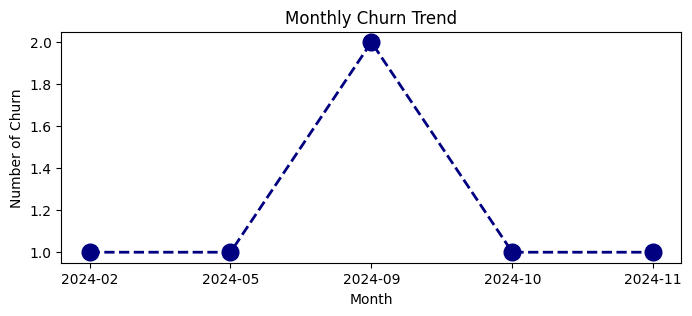

In [55]:
#4.1  Monthly churn Trend (Time series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend= df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8, 3))
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Number of Churn')
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='navy', marker='o', linestyle ="dashed", linewidth = 2, markersize = 12)
plt.show()

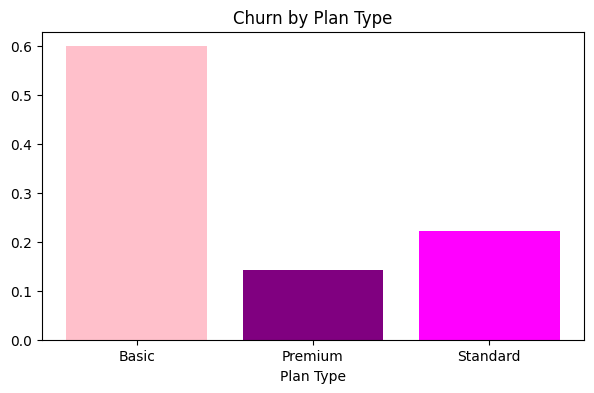

In [56]:
#4.2  churn by plan type

churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = ['pink','purple','magenta']
plt.figure(figsize=(7, 4))
plt.bar(churn_plan.index, churn_plan.values,color = colors)
plt.title('Churn by Plan Type')
plt.xlabel('Plan Type')
plt.show()

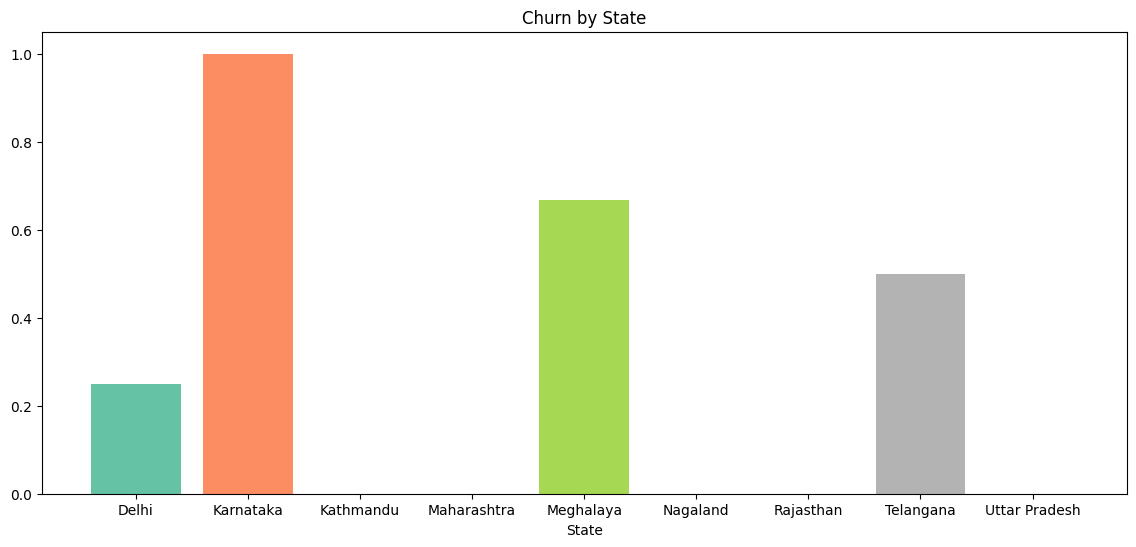

In [57]:
#4.3  churn by states

churn_plan = df_visual.groupby('state')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))
plt.figure(figsize=(14, 6))
plt.bar(churn_plan.index, churn_plan.values,color = colors)
plt.title('Churn by State')
plt.xlabel('State')
plt.show()


In [58]:
#visualazation using seaborn



In [59]:
#encoding ----  convert str to numeric so that we can find corr between features
#df_encoded =
df_visual[['plan_type', 'contract_type','churn_score',
       'churn_flag','escalations', 'churn_risk']].head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,Standard,Annual,12,0,NaN,Low
1,Premium,Annual,91,1,Y,High
2,Basic,Monthly,34,0,NaN,Low
3,Premium,Annual,8,0,NaN,Low
4,Standard,Monthly,88,1,Y,High


In [63]:
  #correct method of encoding -- based on priority

df_encoded = df_visual[['plan_type', 'contract_type','churn_score',
       'churn_flag', 'churn_risk' ,'escalations']]

order_mappings= {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type': ['Monthly' , 'Annual'],
    'churn_risk': ['Low', 'Medium', 'High']
}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes




/tmp/ipykernel_1721/848410065.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes
/tmp/ipykernel_1721/848410065.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes
/tmp/ipykernel_1721/848410065.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [64]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

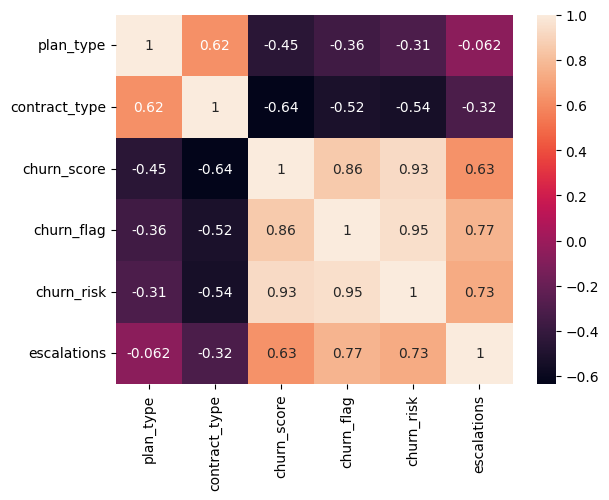

In [65]:
#heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True,)

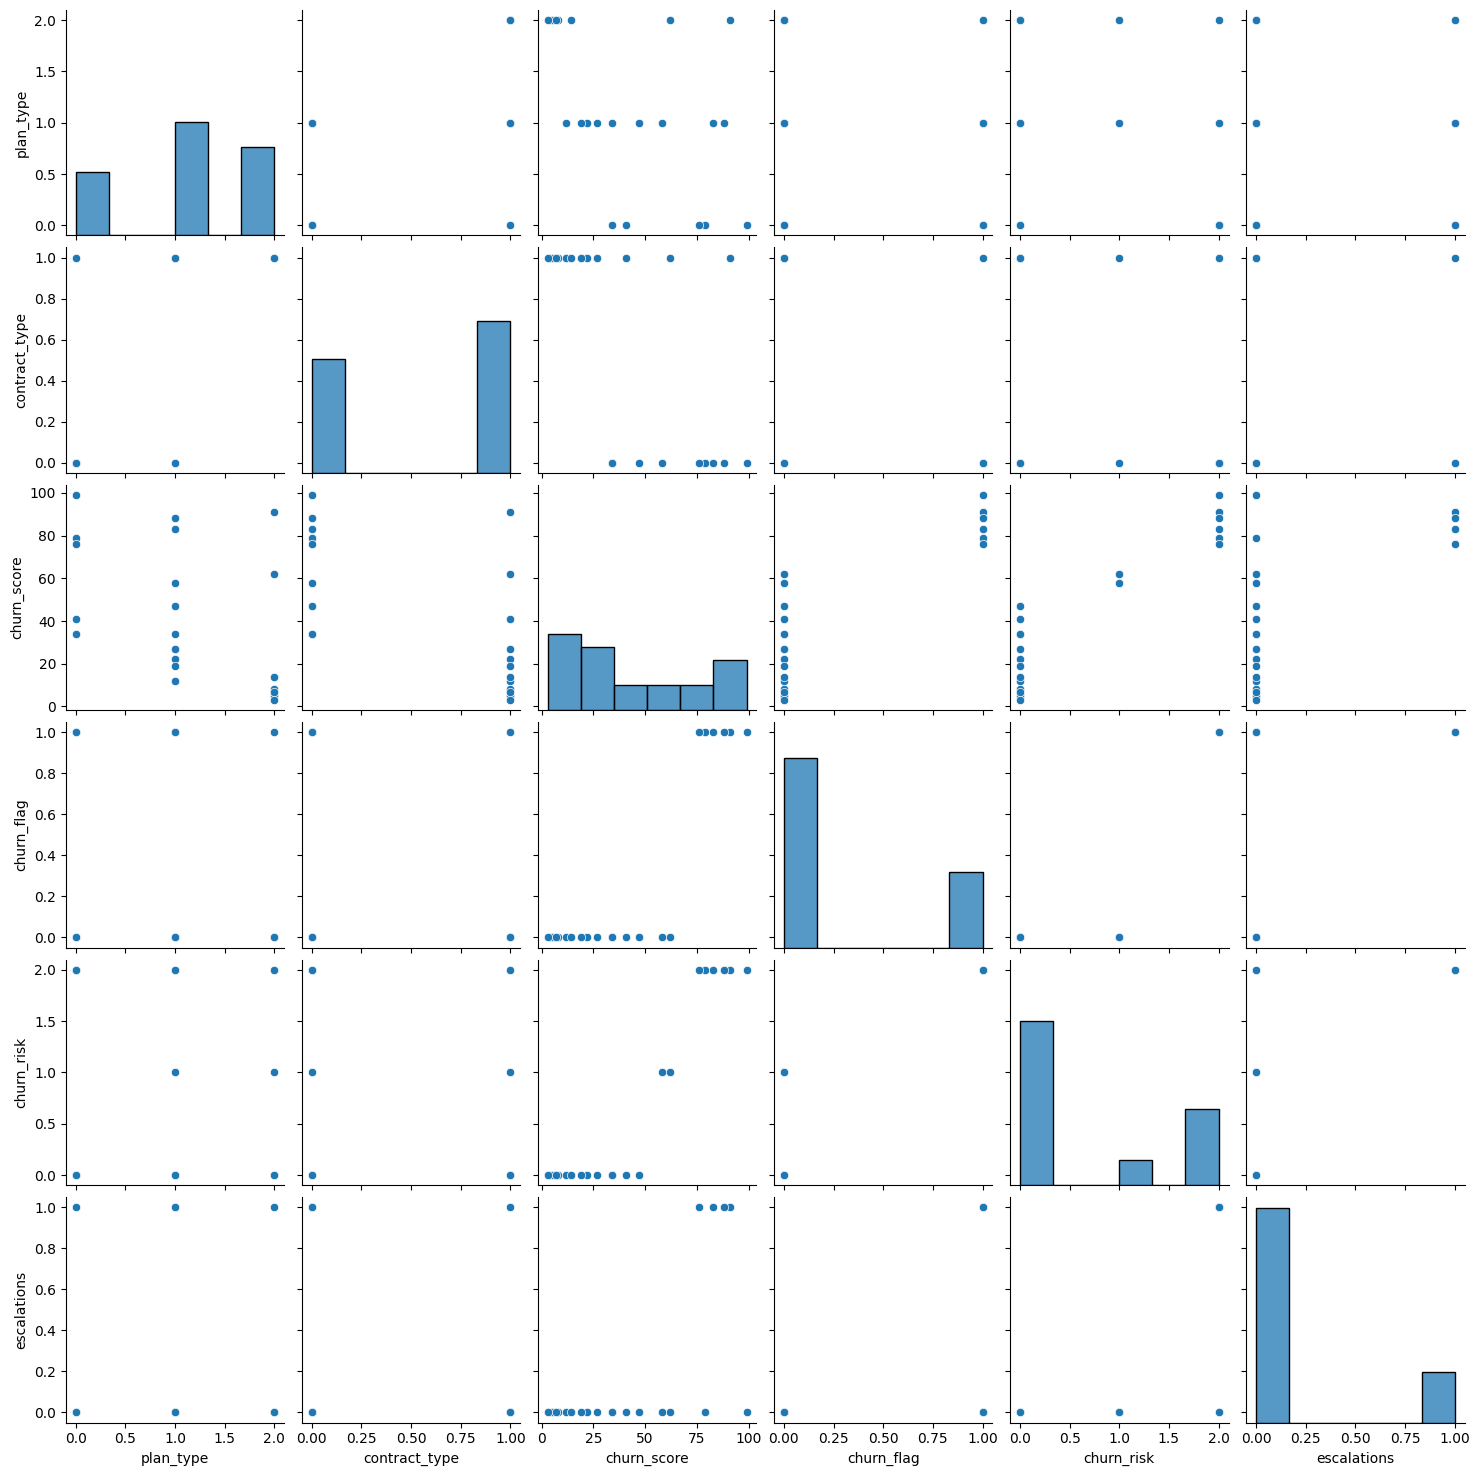

In [66]:
#pairplot - relationship in a dataset

sns.pairplot(df_encoded)

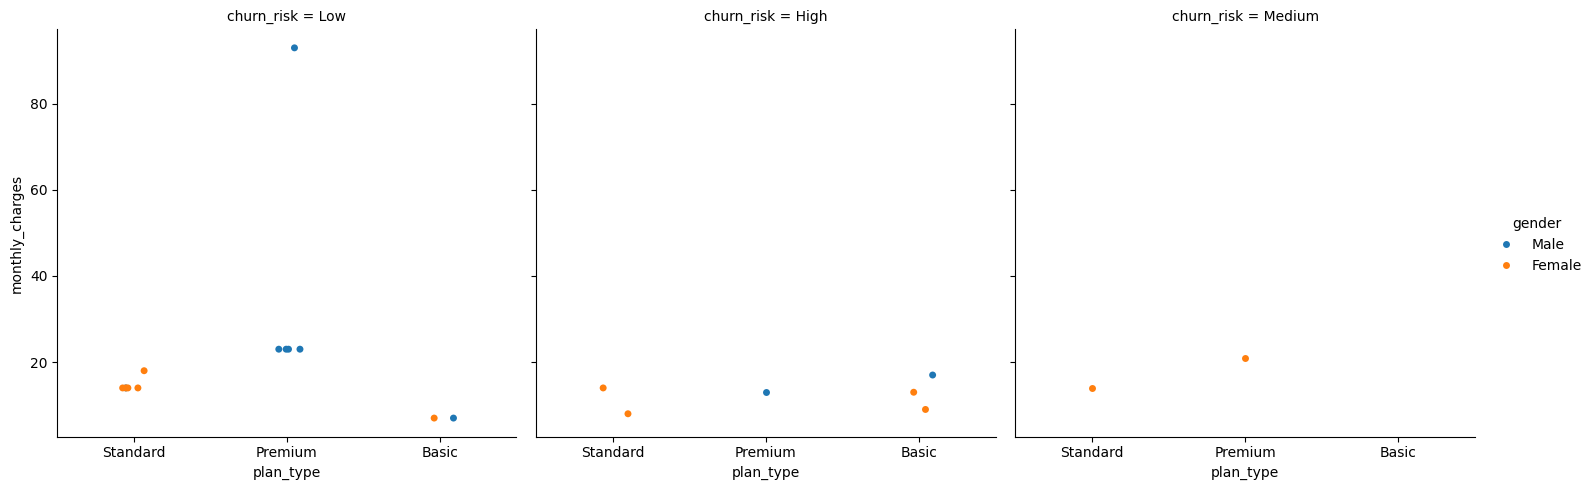

In [68]:
#catplt/facegrid plot -

sns.catplot(data=df_visual, x='plan_type', y='monthly_charges',hue= 'gender',col='churn_risk')

In [69]:
#pivot table

pd.pivot_table(df_visual, values='churn_flag', index='plan_type', aggfunc='mean')

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [70]:
#pivot table

pd.pivot_table(df_visual, index='plan_type',
               values= ['monthly_charges' , 'customerid' , 'churn_flag'],
               aggfunc={
                   'monthly_charges' : 'sum' ,
                    'customerid' : 'nunique',
                    'churn_flag' : 'mean'
                    }
                )

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [71]:
#working with sql in python

conn = sqlite3.connect('test_database.sqlite')

#table details
conn.execute("CREATE TABLE users (first_name TEXT , country TEXT , budget INTEGER)")

#COMMIT AND SAVE
conn.commit()

In [81]:
#insert data

cursor = conn.cursor()

#write sql query to insert records in sql table
cursor.execute(
    """
    INSERT INTO users VALUES
    ('Madhav' , 'India' , 5000),
    ('Rishabh' , 'London' , 2500),
    ('Jiya', 'India',3800)

  """
)

#commit and save
conn.commit()

print("Data inserted successfully")

Data inserted successfully


In [82]:
#check inserted data in table

conn = sqlite3.connect('test_database.sqlite')
query = """SELECT * FROM users"""

df_results = pd.read_sql(query, conn)
df_results.head()

,first_name,country,budget
0,Madhav,india,5000
1,Rishabh,London,2500
2,Jiya,India,3800
3,Madhav,india,5000
4,Rishabh,London,2500


In [62]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month', 'escalations_raw'],
      dtype='object')